In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import joblib

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

plt.rcParams["figure.figsize"] = (10,6)

In [2]:
model = joblib.load("../models/final_model.pkl")

In [3]:
df = pd.read_csv(
    "../data/processed/vessel_arrival_delay_feature_engineered.csv"
)

In [4]:
feature_columns = [

    "Carrier",
    "Vessel_Type",
    "Origin_Port",
    "Destination_Port",

    "Distance_NM",
    "Scheduled_Transit_Days",
    "Departure_Delay_Hours",
    "Average_Speed_Knots",
    "Vessel_Age",
    "Cargo_Load_Percentage",
    "Port_Congestion_Index",
    "Weather_Severity",
    "Fuel_Price_USD",
    "Historical_Route_Delay",

    "Season",
    "Customs_Clearance_Risk",

    "Route",
    "Congestion_Level",
    "Weather_Category",
    "Vessel_Age_Group",
    "Load_Category",
    "Speed_Category",

    "Delay_Risk_Score"

]

In [5]:
X = df[feature_columns]

In [6]:
preprocessor = model.named_steps["preprocessor"]

classifier = model.named_steps["classifier"]

In [7]:
X_processed = preprocessor.transform(X)

# convert sparse matrix to dense

if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()

In [8]:
feature_names = preprocessor.get_feature_names_out()

print(len(feature_names))

155


In [9]:
sample_size = 500

sample_idx = np.random.choice(
    X_processed.shape[0],
    sample_size,
    replace=False
)

X_sample = X_processed[sample_idx]

In [10]:
explainer = shap.Explainer(
    classifier
)

In [11]:
shap_values = explainer(
    X_sample
)

In [12]:
print(shap_values.shape)

(500, 155, 2)


In [13]:
shap_class1 = shap_values[:,:,1]

In [14]:
print(shap_class1.shape)

(500, 155)


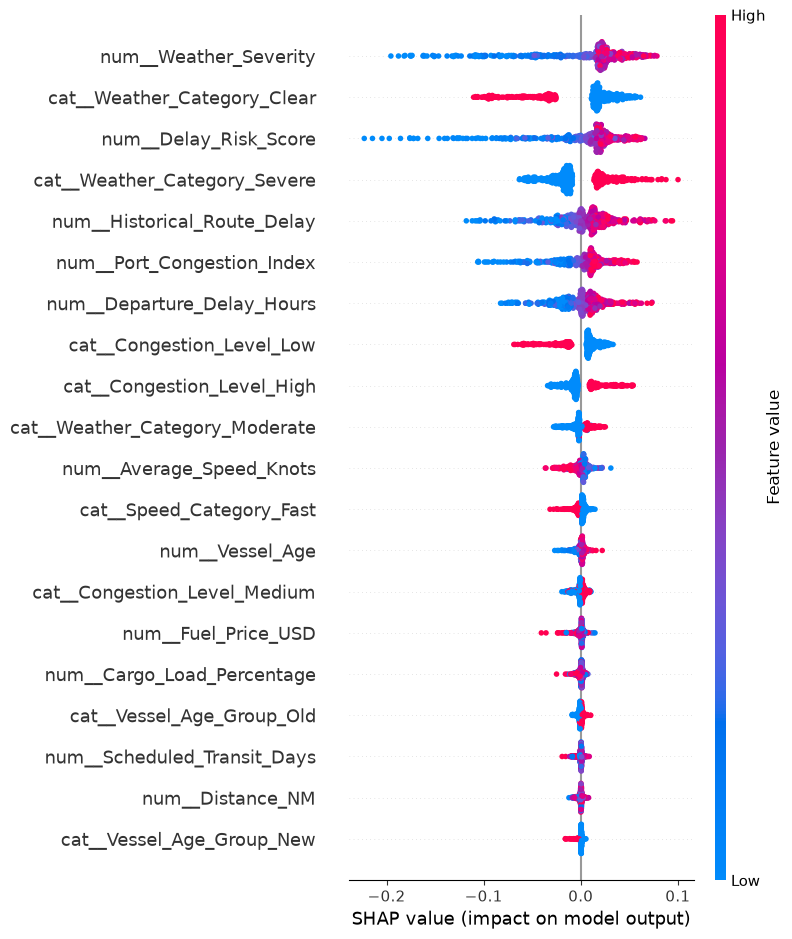

In [15]:
shap.summary_plot(
    shap_class1,
    X_sample,
    feature_names=feature_names
)

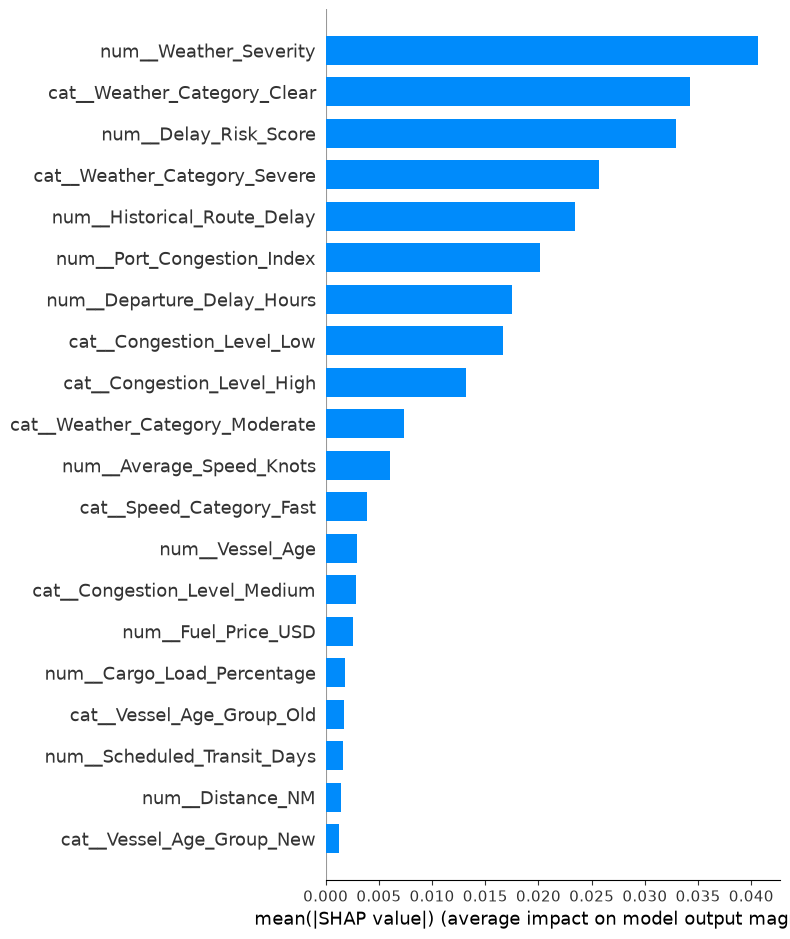

In [16]:
shap.summary_plot(
    shap_class1,
    X_sample,
    feature_names=feature_names,
    plot_type="bar"
)

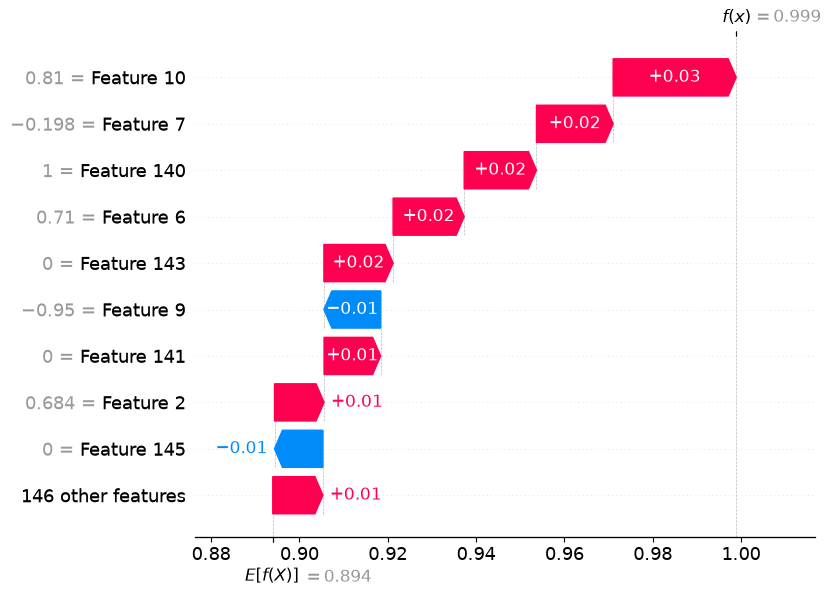

In [17]:
sample = 10

shap.plots.waterfall(
    shap_class1[sample]
)

In [18]:
shap.initjs()

shap.plots.force(
    shap_class1[sample]
)

In [19]:
shap.plots.scatter(
    shap_class1[:, "num__Departure_Delay_Hours"]
)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

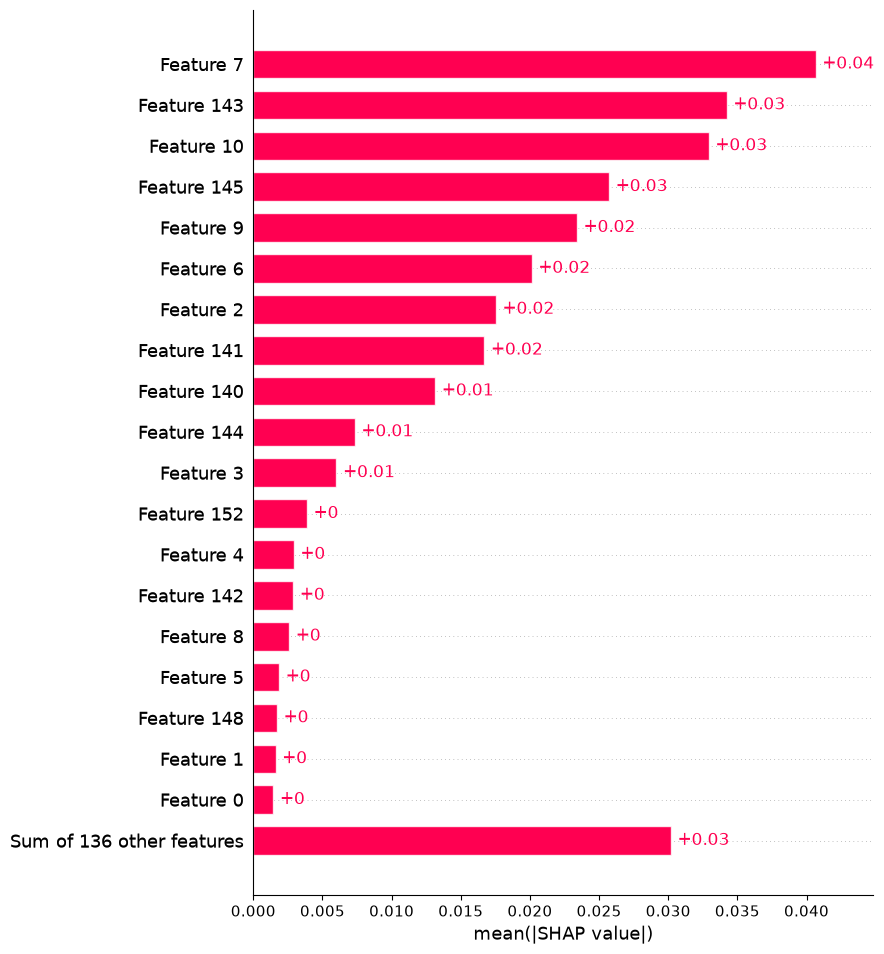

In [20]:
shap.plots.bar(
    shap_class1,
    max_display=20
)

In [21]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(shap_class1.values).mean(axis=0)
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
7,num__Weather_Severity,0.040662
143,cat__Weather_Category_Clear,0.034227
10,num__Delay_Risk_Score,0.032930
145,cat__Weather_Category_Severe,0.025723
9,num__Historical_Route_Delay,0.023397
6,num__Port_Congestion_Index,0.020128
2,num__Departure_Delay_Hours,0.017538
141,cat__Congestion_Level_Low,0.016704
140,cat__Congestion_Level_High,0.013150
144,cat__Weather_Category_Moderate,0.007335


In [22]:
importance_df.to_csv(
    "../reports/shap_feature_importance.csv",
    index=False
)

In [23]:
result = permutation_importance(
    model,
    X,
    df["Late_Arrival"],
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

perm_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": result.importances_mean
}).sort_values("Importance", ascending=False)

perm_df.head(20)

,Feature,Importance
18,Weather_Category,0.028566
11,Weather_Severity,0.015614
13,Historical_Route_Delay,0.013106
22,Delay_Risk_Score,0.010302
6,Departure_Delay_Hours,0.006882
17,Congestion_Level,0.005064
10,Port_Congestion_Index,0.002611
7,Average_Speed_Knots,0.001930
21,Speed_Category,0.001773
8,Vessel_Age,0.001191


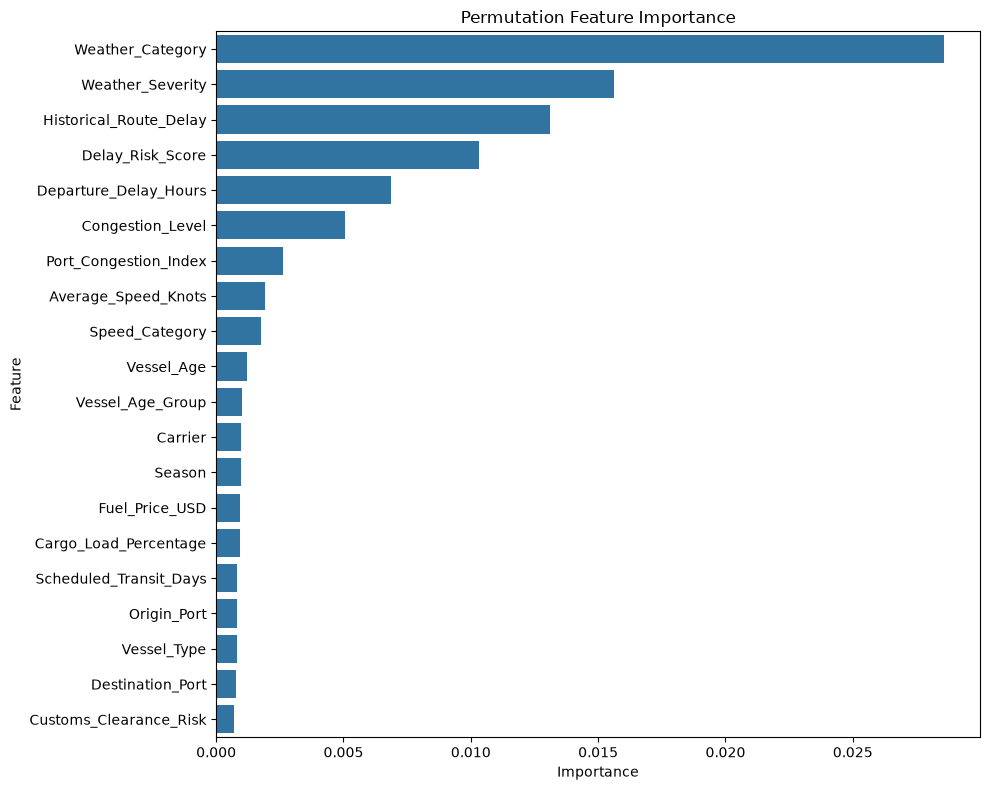

In [24]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=perm_df.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Permutation Feature Importance")

plt.tight_layout()

plt.show()